In [118]:
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import pyomo.environ as pyo
import numpy as np
import matplotlib.pyplot as plt
import copy

net = pn.create_cigre_network_lv() #pn.case5() 

In [119]:
class DSO:
    def __init__(self, flex_price, P_lec_imp, P_lec_exp, VOLL,
                 S_base_MVA=100, V_base_kV=11, roh=0.1):
        self.T = 24
        self.buses = {}
        self.lines = {}
        self.loads = {}
        self.lecs = {}

        # Grid import/export limits in kW
        self.grid_limit = 1000

        # Input data (all in kW)
        self.flex_price = flex_price
        self.P_lec_imp = P_lec_imp  # dict keyed by (t, bus)
        self.P_lec_exp = P_lec_exp  # dict keyed by (t, bus)
        self.VOLL = VOLL
        self.roh = roh

        # Per-unit conversion bases
        self.S_base_MVA = S_base_MVA
        self.S_base_kW = S_base_MVA * 1000  # Convert to kW
        self.V_base_kV = V_base_kV

    # -----------------------
    # System definitions
    # -----------------------
    def add_buses(self, bus_df):
        """Add buses from DataFrame with columns: Bus, Type"""
        for _, row in bus_df.iterrows():
            self.buses[row['Bus']] = {'Type': row['Type']}

    def add_lines(self, line_df):
        """
        Add lines from DataFrame
        Expected columns: From, To, X_ohm, Pline_limit
        Converts reactance to per-unit based on S_base and V_base
        """
        for _, row in line_df.iterrows():
            line_id = f"{row['From']}_{row['To']}"
            # Convert ohms to per-unit: X_pu = X_ohm * S_base / V_base^2
            # (using same simplified unit treatment as originally)
            X_pu = row['X_ohm'] * self.S_base_MVA / (self.V_base_kV ** 2)
            self.lines[line_id] = {
                'from': row['From'],
                'to': row['To'],
                'X_pu': X_pu,
                'X_ohm': row['X_ohm'],
                'Pline_limit': row['Pline_limit']
            }

    def add_loads(self, load_df):
        """
        Add loads from DataFrame
        Expected columns: Bus, 0, 1, 2, ..., T-1 (loads in kW)
        """
        T = self.T
        for _, row in load_df.iterrows():
            bus = row['Bus']
            for t in range(T):
                if t not in row.index:
                    raise KeyError(f"Missing column {t} in load_df")
                self.loads[(bus, t)] = row[t]  # kW

    def add_lecs(self, lec_bus_list):
        """Define which buses have LECs"""
        for b in lec_bus_list:
            self.lecs[b] = True

    def set_grid_limit(self, p_grid_limit=1000):
        """Set grid import/export limit in kW"""
        self.grid_limit = p_grid_limit

    def validate_data(self):
        """Validate that required data is present"""
        if not self.buses:
            raise ValueError("No buses defined.")
        if not self.loads:
            raise ValueError("No loads defined.")
        slack_buses = [b for b, info in self.buses.items() if info['Type'] == 'slack']
        if not slack_buses:
            raise ValueError("No slack bus defined.")

    # -----------------------
    # Build DC OPF model
    # -----------------------
    def build_dc_opf(self):
        """Build the DC Optimal Power Flow model with proper unit handling"""
        self.validate_data()

        model = pyo.ConcreteModel()
        T = self.T

        model.T = pyo.Set(initialize=range(T))
        model.B = pyo.Set(initialize=list(self.buses.keys()))
        model.L = pyo.Set(initialize=list(self.lines.keys()))

        slack_bus = [b for b, info in self.buses.items() if info['Type'] == 'slack'][0]

        # -------------------------
        # Variables (all in kW except angles)
        # -------------------------
        model.Pshed = pyo.Var(model.T, model.B, within=pyo.NonNegativeReals)

        # Voltage angles in radians (unbounded is also OK but keep reasonable bounds)
        model.theta = pyo.Var(model.T, model.B, bounds=(-np.pi, np.pi))

        # Line flows in kW (will convert to/from per-unit internally)
        # Individual line limits will be enforced with constraints below.
        model.P_line = pyo.Var(model.T, model.L, bounds=(-self.grid_limit, self.grid_limit))

        # Grid import/export in kW (single global grid interaction at slack bus)
        model.P_grid_import = pyo.Var(model.T, bounds=(0, self.grid_limit))
        model.P_grid_export = pyo.Var(model.T, bounds=(0, self.grid_limit))

        # LEC import/export in kW for every bus (but only LEC buses will appear in objective/constraints)
        model.P_dso_import = pyo.Var(model.T, model.B, bounds=(0, self.grid_limit))
        model.P_dso_export = pyo.Var(model.T, model.B, bounds=(0, self.grid_limit))

        # -------------------------
        # Objective function
        # -------------------------
        def obj_rule(m):
            # Load shedding cost
            Pshed_cost = sum(m.Pshed[t, b] * self.VOLL for t in m.T for b in m.B)

            # ADMM-like penalty for LEC deviations (only for LEC buses)
            penalty_cost = (sum(self.flex_price[t]*(m.P_dso_import[t, b] - m.P_dso_export[t, b])
                               for t in m.T for b in self.lecs) +
                            (self.roh / 2) * sum(((self.P_lec_imp.get((t, b), 0.0)-self.P_lec_exp.get((t, b), 0.0))
                                 +(m.P_dso_import[t, b] - m.P_dso_export[t, b]))**2 for t in m.T for b in self.lecs))

            return Pshed_cost + penalty_cost

        model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

        # -------------------------
        # Constraints
        # -------------------------

        # Fix slack bus angle to zero
        def slack_angle_rule(m, t):
            return m.theta[t, slack_bus] == 0
        model.slack_angle = pyo.Constraint(model.T, rule=slack_angle_rule)

        # DC power flow equations: P_kW = (θ_from - θ_to) / X_pu * S_base_kW
        def line_flow_rule(m, t, l):
            line_data = self.lines[l]
            X_pu = line_data['X_pu']
            # protect against zero reactance
            if abs(X_pu) < 1e-12:
                return pyo.Constraint.Skip
            theta_from = m.theta[t, line_data['from']]
            theta_to = m.theta[t, line_data['to']]
            return m.P_line[t, l] == ((theta_from - theta_to) / X_pu) * self.S_base_kW
        model.line_flow = pyo.Constraint(model.T, model.L, rule=line_flow_rule)

        # Line flow limits (use per-line Pline_limit, they are in kW already)
        def line_flow_limit_rule_upper(m, t, l):
            return m.P_line[t, l] <= self.lines[l]['Pline_limit']
        model.line_flow_limit_upper = pyo.Constraint(model.T, model.L, rule=line_flow_limit_rule_upper)

        def line_flow_limit_rule_lower(m, t, l):
            return m.P_line[t, l] >= -self.lines[l]['Pline_limit']
        model.line_flow_limit_lower = pyo.Constraint(model.T, model.L, rule=line_flow_limit_rule_lower)

        # Power balance at each bus (all in kW)
        def power_balance_rule(m, t, b):
            # Generation at slack bus represented by grid import-export at slack
            P_gen = (m.P_grid_import[t] - m.P_grid_export[t]) if b == slack_bus else 0.0

            # Load (after shedding)
            P_load = self.loads.get((b, t), 0.0)

            # Shedding power
            P_shed = m.Pshed[t, b]

            # LEC net power (import - export) only if bus is a LEC
            P_lec = (m.P_dso_export[t, b] - m.P_dso_import[t, b]) if (b in self.lecs) else 0.0

            # Net line flow (positive = leaving bus)
            line_sum = sum(
                (m.P_line[t, l] if self.lines[l]['from'] == b else
                 -m.P_line[t, l] if self.lines[l]['to'] == b else 0)
                for l in self.lines.keys()
            )

            # Power balance: generation - (load - shed) - LEC = net outflow
            return P_gen - (P_load - P_shed) - P_lec == 0 #line_sum

        model.power_balance = pyo.Constraint(model.T, model.B, rule=power_balance_rule)

        isolated_buses = []
        for b in self.buses:
            connected = any(
                self.lines[l]['from'] == b or self.lines[l]['to'] == b
                for l in self.lines
            )
            if not connected and self.buses[b]['Type'] != 'slack':
                isolated_buses.append(b)

        def fix_isolated_angles(m, t, b):
            if b in isolated_buses:
                return m.theta[t, b] == 0
            return pyo.Constraint.Skip

        model.fix_isolated = pyo.Constraint(model.T, model.B, rule=fix_isolated_angles)

        return model

    # -----------------------
    # Solve
    # -----------------------
    def solve_dc_opf(self, solver_name='gurobi', verbose=False):
        """
        Solve the DC OPF problem

        Parameters:
        -----------
        solver_name : str
            Solver to use (default 'glpk')
        verbose : bool
            Print solver output (default False)

        Returns:
        --------
        dict : Solution with all results in kW
        """
        model = self.build_dc_opf()
        solver = pyo.SolverFactory('gurobi')

        if not solver.available():
            raise RuntimeError(f"Solver '{solver_name}' is not available on this system.")

        res = solver.solve(model, tee=verbose)

        if res.solver.termination_condition != pyo.TerminationCondition.optimal:
            print(f"Warning: Solver status = {res.solver.status}")
            print(f"Termination condition = {res.solver.termination_condition}")

        # Extract results (all in kW)
        P_line = {(t, l): pyo.value(model.P_line[t, l]) for t in model.T for l in model.L}
        P_grid_import = {t: pyo.value(model.P_grid_import[t]) for t in model.T}
        P_grid_export = {t: pyo.value(model.P_grid_export[t]) for t in model.T}
        P_dso_import = {(t, b): pyo.value(model.P_dso_import[t, b]) for t in model.T for b in self.lecs.keys()}
        P_dso_export = {(t, b): pyo.value(model.P_dso_export[t, b]) for t in model.T for b in self.lecs.keys()}
        theta = {(t, b): pyo.value(model.theta[t, b]) for t in model.T for b in model.B}
        Pshed = {(t, b): pyo.value(model.Pshed[t, b]) for t in model.T for b in model.B}

        return {
            'P_line': P_line,  # kW
            'P_grid_import': P_grid_import,  # kW
            'P_grid_export': P_grid_export,  # kW
            'P_dso_import': P_dso_import,  # kW
            'P_dso_export': P_dso_export,  # kW
            'theta': theta,  # radians
            'Pshed': Pshed,  # kW
            'objective': pyo.value(model.obj),  # $
            'solver_res': res
        }

    def get_results_dataframe(self, results):
        """Convert results dictionary to pandas DataFrame"""
        T = self.T

        data = {
            'Time': list(range(T)),
            'P_grid_import': [results['P_grid_import'][t] for t in range(T)],
            'P_grid_export': [results['P_grid_export'][t] for t in range(T)],
            'Net_import_kW': [results['P_grid_import'][t] - results['P_grid_export'][t] for t in range(T)]
        }

        # Add line flows
        for line in self.lines:
            data[f'P_line_{line}_kW'] = [results['P_line'][(t, line)] for t in range(T)]

        # Add load shedding
        for bus in self.buses:
            data[f'Pshed_{bus}_kW'] = [results['Pshed'][(t, bus)] for t in range(T)]

        return pd.DataFrame(data)


In [120]:
class charging_point():
    def __init__(self, name, ev_capacity, ev_max_power, ev_arrival_soc, ev_arrival, ev_departure, ev_desired_soc):
        self.efficiency = 0.93
        # Input validation using assertions
        assert isinstance(ev_capacity, list), "ev_capacity must be a list"
        assert isinstance(ev_max_power, list), "ev_max_power must be a list"
        assert isinstance(ev_arrival_soc, list), "ev_arrival_soc must be a list"
        assert isinstance(ev_arrival, list), "ev_arrival must be a list"
        assert isinstance(ev_departure, list), "ev_departure must be a list"
        assert isinstance(ev_desired_soc, list), "ev_desired_soc must be a list"

        assert len(ev_arrival) == len(ev_departure), "ev_arrival and ev_departure must have the same length"
        assert len(ev_arrival) == len(ev_desired_soc), "ev_arrival and ev_desired_soc must have the same length"
        assert len(ev_arrival_soc) == len(ev_desired_soc), "ev_arrival_soc and ev_desired_soc must have the same length"
        assert len(ev_capacity) == len(ev_desired_soc), "ev_capacity and ev_desired_soc must have the same length"
        assert len(ev_max_power) == len(ev_desired_soc), "ev_max_power and ev_desired_soc must have the same length"

        for i in range(len(ev_arrival)):
            assert ev_arrival[i] < ev_departure[i], f"ev_arrival[{i}] must be less than ev_departure[{i}]"
            assert 0.2 <= ev_arrival_soc[i] <= 1, f"ev_arrival_soc[{i}] must be between 0.2 and 1"
            assert 0 <= ev_desired_soc[i] <= 1, f"ev_desired_soc[{i}] must be between 0 and 1"
            min_time_to_charge = ev_departure[i] - ev_arrival[i]
            min_req_charge = (ev_desired_soc[i] - ev_arrival_soc[i]) * ev_capacity[i] / self.efficiency
            min_req_charge_per_time = min_req_charge / min_time_to_charge
            assert min_req_charge_per_time <= ev_max_power[
                i], f"min_req_charge_per_time ({min_req_charge_per_time:.2f}) must be less than or equal to ev_max_power[{i}] ({ev_max_power[i]}) for {name}"

        self.name = name
        self.ev_capacity = ev_capacity
        self.ev_max_power = ev_max_power
        self.ev_arrival_soc = ev_arrival_soc
        self.ev_desired_soc = ev_desired_soc
        self.ev_arrival = ev_arrival
        self.ev_departure = ev_departure
        self.num_evs = len(ev_capacity)  # Store the number of EVs


class building():
    def __init__(self, name, load, pv_production, bess_capacity, bess_max_power, bess_initial_soc):
        self.efficiency = 0.93
        self.name = name
        self.load = load
        self.pv_production = pv_production
        self.bess_capacity = bess_capacity
        self.bess_max_power = bess_max_power
        self.bess_initial_soc = bess_initial_soc


class lec_opt():
    def __init__(self, charging_points, buildings, spot_prices, flex_price, P_dso_import,
                 P_dso_export, previous_monthly_peak=0, v2g_on=1, incentive_per_kwh=0.1, roh=0.1):
        self.M = 10000
        self.roh = roh
        self.charging_points = charging_points
        self.buildings = buildings
        self.spot_prices = spot_prices
        self.incentive_per_kwh = incentive_per_kwh
        self.v2g_on = v2g_on
        self.previous_monthly_peak = previous_monthly_peak
        self.flex_price = flex_price
        self.P_dso_import = P_dso_import
        self.P_dso_export = P_dso_export
        self.model = pyo.ConcreteModel()
        self.build_model()

    def build_model(self):
        self.model.T = pyo.Set(initialize=range(len(self.spot_prices)))
        self.model.spot_prices = self.spot_prices
        self.model.previous_monthly_peak = self.previous_monthly_peak
        self.model.monthly_peak = pyo.Var(initialize=0)
        self.model.P_im_grid = pyo.Var(self.model.T, within=pyo.NonNegativeReals, bounds=(0, 20000))
        self.model.P_ex_grid = pyo.Var(self.model.T, within=pyo.NonNegativeReals, bounds=(0, 20000))
        self.model.B_im_grid = pyo.Var(self.model.T, within=pyo.Binary)
        self.model.Peakload = pyo.Var(within=pyo.NonNegativeReals)
        self.model.transmission_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.supplier_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.overall_dso_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.tax_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.peak_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.Subscription_fee = 605 / 30  # Subscription fee SEK/14 days
        self.model.Transmission_fee = 0.113  # Electricity transmission fee SEK/kWh
        self.model.Transmission_health_incentive = 0.04  # Transmission health incentive SEK/kWh
        self.model.Effect_fee = 61.55 / 30  # Effect fee SEK/kW/14 days
        self.model.Energy_tax = 0.439  # Tax fee SEK/kWh
        self.model.Energy_certificate = 0.005  # Energy certificate SEK/kWh
        self.model.compensation_fee = 0.02  # Transfer compensation fee SEK/kWh
        self.model.peak_cost_scaling_factor = 5 #In the ojective to peanalize high peaks in long-term

        for charge_point in self.charging_points:
            setattr(self.model, f'{charge_point.name}_P',
                    pyo.Var(self.model.T, within=pyo.Reals, bounds=(-1000000, 1000000)))

            # Iterate through each EV at the charging point
            for ev_index in range(charge_point.num_evs):
                ev_name = f'{charge_point.name}_ev{ev_index}'  # Unique name for each EV
                setattr(self.model, f'{ev_name}_ch', pyo.Var(self.model.T, within=pyo.NonNegativeReals,
                                                             bounds=(0, charge_point.ev_max_power[ev_index])))
                setattr(self.model, f'{ev_name}_ds', pyo.Var(self.model.T, within=pyo.NonNegativeReals, bounds=(0,
                                                                                                                self.v2g_on *
                                                                                                                charge_point.ev_max_power[
                                                                                                                    ev_index])))
                setattr(self.model, f'{ev_name}_soc', pyo.Var(self.model.T, within=pyo.NonNegativeReals, bounds=(0, 1)))
                setattr(self.model, f'{ev_name}_Bch', pyo.Var(self.model.T, within=pyo.Binary))

                ev_capacity = charge_point.ev_capacity[ev_index]
                ev_arrival_soc = charge_point.ev_arrival_soc[ev_index]
                ev_arrival = charge_point.ev_arrival[ev_index]
                ev_departure = charge_point.ev_departure[ev_index]
                ev_desired_soc = charge_point.ev_desired_soc[ev_index]

                def ev_soc_rule(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_ch = getattr(model, f'{ev_name}_ch')[t]
                    ev_ds = getattr(model, f'{ev_name}_ds')[t]
                    ev_soc = getattr(model, f'{ev_name}_soc')[t]
                    if t == ev_arrival:
                        return ev_soc == ev_arrival_soc + (
                                    ev_ch * charge_point.efficiency - ev_ds / charge_point.efficiency) / ev_capacity
                    elif ev_arrival < t <= ev_departure:
                        ev_previous_soc = getattr(model, f'{ev_name}_soc')[t - 1]
                        return ev_soc == ev_previous_soc + (
                                    ev_ch * charge_point.efficiency - ev_ds / charge_point.efficiency) / ev_capacity
                    else:
                        return pyo.Constraint.Skip

                setattr(self.model, f'{ev_name}_soc_constraint', pyo.Constraint(self.model.T, rule=ev_soc_rule))

                def ev_soc_min_rule(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_soc = getattr(model, f'{ev_name}_soc')[t]
                    ev_arrival = charge_point.ev_arrival[ev_index]
                    ev_departure = charge_point.ev_departure[ev_index]
                    if ev_arrival <= t <= ev_departure:
                        return ev_soc >= 0.2
                    return ev_soc == 0

                setattr(self.model, f'{ev_name}_soc_min_constraint', pyo.Constraint(self.model.T, rule=ev_soc_min_rule))

                def ev_max_ch(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_Bch = getattr(model, f'{ev_name}_Bch')[t]
                    ev_ch = getattr(model, f'{ev_name}_ch')[t]
                    return ev_ch <= ev_Bch * charge_point.ev_max_power[ev_index]

                setattr(self.model, f'{ev_name}_max_ch_constraint', pyo.Constraint(self.model.T, rule=ev_max_ch))

                def ev_max_ds(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_Bch = getattr(model, f'{ev_name}_Bch')[t]
                    ev_ds = getattr(model, f'{ev_name}_ds')[t]
                    return ev_ds <= (1 - ev_Bch) * charge_point.ev_max_power[ev_index]

                setattr(self.model, f'{ev_name}_max_ds_constraint', pyo.Constraint(self.model.T, rule=ev_max_ds))

                def ev_avail_ch(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_ch = getattr(model, f'{ev_name}_ch')[t]
                    if charge_point.ev_arrival[ev_index] < t < charge_point.ev_departure[ev_index]:
                        return ev_ch >= 0
                    return ev_ch == 0

                setattr(self.model, f'{ev_name}_avail_ch_constraint', pyo.Constraint(self.model.T, rule=ev_avail_ch))

                def ev_avail_ds(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_ds = getattr(model, f'{ev_name}_ds')[t]
                    if charge_point.ev_arrival[ev_index] < t < charge_point.ev_departure[ev_index]:
                        return ev_ds >= 0
                    return ev_ds == 0

                setattr(self.model, f'{ev_name}_avail_ds_constraint', pyo.Constraint(self.model.T, rule=ev_avail_ds))

                def ev_desired_soc(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_soc = getattr(model, f'{ev_name}_soc')[t]
                    if t == charge_point.ev_departure[ev_index]:
                        return ev_soc >= charge_point.ev_desired_soc[ev_index]
                    return pyo.Constraint.Skip

                setattr(self.model, f'{ev_name}_desired_soc_constraint',
                        pyo.Constraint(self.model.T, rule=ev_desired_soc))

            def consumption(model, t, charge_point=charge_point):
                P = getattr(model, f'{charge_point.name}_P')[t]
                ev_power = sum(getattr(model, f'{charge_point.name}_ev{ev_index}_ch')[t] -
                               getattr(model, f'{charge_point.name}_ev{ev_index}_ds')[t] for ev_index in
                               range(charge_point.num_evs))
                return ev_power == P

            setattr(self.model, f'{charge_point.name}_consumption_constraint',
                    pyo.Constraint(self.model.T, rule=consumption))

        # Building constraints:
        for building in self.buildings:
            setattr(self.model, f'{building.name}_P',
                    pyo.Var(self.model.T, within=pyo.Reals, bounds=(-1000000, 1000000)))
            setattr(self.model, f'{building.name}_bess_soc', pyo.Var(self.model.T, within=pyo.Reals, bounds=(0, 1)))
            setattr(self.model, f'{building.name}_bess_ch',
                    pyo.Var(self.model.T, within=pyo.Reals, bounds=(0, building.bess_max_power)))
            setattr(self.model, f'{building.name}_bess_ds',
                    pyo.Var(self.model.T, within=pyo.Reals, bounds=(0, building.bess_max_power)))
            setattr(self.model, f'{building.name}_bess_Bch', pyo.Var(self.model.T, within=pyo.Binary))

            def bess_soc_rule(model, t, building=building):
                bess_ch = getattr(model, f'{building.name}_bess_ch')[t]
                bess_ds = getattr(model, f'{building.name}_bess_ds')[t]
                bess_soc = getattr(model, f'{building.name}_bess_soc')[t]
                if building.bess_capacity == 0:
                    return bess_soc == 0
                elif t == 0:
                    return bess_soc == building.bess_initial_soc + (
                                bess_ch * building.efficiency - bess_ds / building.efficiency) / building.bess_capacity
                else:
                    bess_previous_soc = getattr(model, f'{building.name}_bess_soc')[t - 1]
                    return bess_soc == bess_previous_soc + (
                                bess_ch * building.efficiency - bess_ds / building.efficiency) / building.bess_capacity

            setattr(self.model, f'{building.name}_bess_soc_constraint',
                    pyo.Constraint(self.model.T, rule=bess_soc_rule))

            def bess_soc_min_rule(model, t, building=building):
                bess_soc = getattr(model, f'{building.name}_bess_soc')[t]
                if building.bess_capacity == 0:
                    return bess_soc == 0
                return bess_soc >= 0.2

            setattr(self.model, f'{building.name}_bess_soc_min_constraint',
                    pyo.Constraint(self.model.T, rule=bess_soc_min_rule))

            def bess_soc_max_rule(model, t, building=building):
                bess_soc = getattr(model, f'{building.name}_bess_soc')[t]
                if building.bess_capacity == 0:
                    return pyo.Constraint.Skip
                return bess_soc <= 1.0

            setattr(self.model, f'{building.name}_bess_soc_max_constraint',
                    pyo.Constraint(self.model.T, rule=bess_soc_max_rule))


            def bess_max_ch(model, t, building=building):
                bess_Bch = getattr(model, f'{building.name}_bess_Bch')[t]
                bess_ch = getattr(model, f'{building.name}_bess_ch')[t]
                if building.bess_capacity == 0:
                    return bess_ch == 0
                return bess_ch <= bess_Bch * building.bess_max_power

            setattr(self.model, f'{building.name}_bess_max_ch_constraint',
                    pyo.Constraint(self.model.T, rule=bess_max_ch))

            def bess_max_ds(model, t, building=building):
                bess_Bch = getattr(model, f'{building.name}_bess_Bch')[t]
                bess_ds = getattr(model, f'{building.name}_bess_ds')[t]
                if building.bess_capacity == 0:
                    return bess_ds == 0
                return bess_ds <= (1 - bess_Bch) * building.bess_max_power

            setattr(self.model, f'{building.name}_bess_max_ds_constraint',
                    pyo.Constraint(self.model.T, rule=bess_max_ds))

            def building_consumption(model, t, building=building):
                P = getattr(model, f'{building.name}_P')[t]
                load = building.load[t]
                pv = building.pv_production[t]
                bess_ch = getattr(model, f'{building.name}_bess_ch')[t]
                bess_ds = getattr(model, f'{building.name}_bess_ds')[t]
                return load - pv - bess_ds + bess_ch == P

            setattr(self.model, f'{building.name}_consumption_constraint',
                    pyo.Constraint(self.model.T, rule=building_consumption))

        def power_balance(model, t):
            overall_consumption = sum(
                getattr(model, f'{charge_point.name}_P')[t] for charge_point in self.charging_points) + \
                                  sum(getattr(model, f'{building.name}_P')[t] for building in self.buildings)
            P_im = self.model.P_im_grid[t]
            P_ex = self.model.P_ex_grid[t]
            return P_im - P_ex == overall_consumption

        self.model.power_balance_constarint = pyo.Constraint(self.model.T, rule=power_balance)

        def power_import(model, t):
            P_im = self.model.P_im_grid[t]
            B_im = self.model.B_im_grid[t]
            return P_im <= self.M * B_im

        self.model.power_import_constraint = pyo.Constraint(self.model.T, rule=power_import)

        def power_export(model, t):
            P_ex = self.model.P_ex_grid[t]
            B_im = self.model.B_im_grid[t]
            return P_ex <= self.M * (1 - B_im)

        self.model.power_export_constraint = pyo.Constraint(self.model.T, rule=power_export)

        def peak_load_constraint(model, t):
            return model.Peakload >= model.P_im_grid[t] - model.P_ex_grid[t]

        self.model.peak_load_constraint = pyo.Constraint(self.model.T, rule=peak_load_constraint)

        def previous_peak_check1(model):
            return model.monthly_peak >= model.Peakload

        self.model.previous_peak_check1_constraint = pyo.Constraint(rule=previous_peak_check1)

        def previous_peak_check2(model):
            return model.monthly_peak >= model.previous_monthly_peak

        self.model.previous_peak_check2_constraint = pyo.Constraint(rule=previous_peak_check2)

        def tranmission_cost(model, t):
            return model.transmission_cost[t] == model.P_im_grid[t] * model.Transmission_fee - model.P_ex_grid[
                t] * model.Transmission_health_incentive

        self.model.tranmission_cost_constraint = pyo.Constraint(self.model.T, rule=tranmission_cost)

        def supplier_cost(model, t):
            return model.supplier_cost[t] == model.P_im_grid[t] * (model.spot_prices[t] + model.Energy_certificate) - \
                model.P_ex_grid[t] * (model.spot_prices[t] + model.Energy_certificate + model.compensation_fee)

        self.model.supplier_cost_constraint = pyo.Constraint(self.model.T, rule=supplier_cost)

        # Base objective: without flex_income and penalty_cost
        def base_objective_rule(model):
            subscription_fee = model.Subscription_fee
            supplier_cost = sum((model.spot_prices[t] + model.Energy_certificate) * model.P_im_grid[t] / 4 - (
                        model.spot_prices[t] + model.Energy_certificate + model.compensation_fee)
                                * model.P_ex_grid[t] / 4 for t in model.T)
            transmission_cost = sum(
                (model.Transmission_fee) * model.P_im_grid[t] / 4 - (model.Transmission_health_incentive)
                * model.P_ex_grid[t] / 4 for t in model.T)
            peak_cost = model.Effect_fee * model.monthly_peak * model.peak_cost_scaling_factor
            dso_cost = transmission_cost + peak_cost + subscription_fee
            tax_cost = (supplier_cost + dso_cost) * 0.25 + (
                        1.25 * model.Energy_tax * sum(model.P_im_grid[t] - model.P_ex_grid[t] for t in model.T) / 4)
            overall_cost = dso_cost + tax_cost + supplier_cost
            return overall_cost

        self.model.base_obj = pyo.Objective(rule=base_objective_rule, sense=pyo.minimize)

        # Extended objective: with flex_income and penalty_cost
        def extended_obj_rule(model):
            subscription_fee = model.Subscription_fee
            supplier_cost = sum((model.spot_prices[t] + model.Energy_certificate) * model.P_im_grid[t] / 4 - (
                        model.spot_prices[t] + model.Energy_certificate + model.compensation_fee)
                                * model.P_ex_grid[t] / 4 for t in model.T)
            transmission_cost = sum(
                (model.Transmission_fee) * model.P_im_grid[t] / 4 - (model.Transmission_health_incentive)
                * model.P_ex_grid[t] / 4 for t in model.T)
            peak_cost = model.Effect_fee * model.monthly_peak * model.peak_cost_scaling_factor
            dso_cost = transmission_cost + peak_cost + subscription_fee
            tax_cost = (supplier_cost + dso_cost) * 0.25 + (
                        1.25 * model.Energy_tax * sum(model.P_im_grid[t] - model.P_ex_grid[t] for t in model.T) / 4)

            penalty_cost = (sum(self.flex_price[t] * (model.P_im_grid[t] - model.P_ex_grid[t]) for t in model.T)
                            + (self.roh / 2) * sum(
                ((model.P_im_grid[t] - model.P_ex_grid[t]) +
                 (self.P_dso_import[t] - self.P_dso_export[t]))** 2 for t in model.T))
            overall_cost = dso_cost + tax_cost + supplier_cost + penalty_cost
            return overall_cost

        self.model.extended_obj = pyo.Objective(rule=extended_obj_rule, sense=pyo.minimize)

    def solve(self, use_extended=False):
        solver = pyo.SolverFactory('gurobi')
        if use_extended:
            self.model.base_obj.deactivate()
            self.model.extended_obj.activate()
        else:
            self.model.extended_obj.deactivate()
            self.model.base_obj.activate()

        self.results = solver.solve(self.model)
        return self.results

    def get_results(self):
        active_obj = self.model.base_obj if self.model.base_obj.active else self.model.extended_obj
        results = {}
        for charge_point in self.charging_points:
            for ev_index in range(charge_point.num_evs):
                ev_name = f'{charge_point.name}_ev{ev_index}'
                results[f'{ev_name}_ch'] = [pyo.value(getattr(self.model, f'{ev_name}_ch')[t]) for t in self.model.T]
                results[f'{ev_name}_ds'] = [pyo.value(getattr(self.model, f'{ev_name}_ds')[t]) for t in self.model.T]
                results[f'{ev_name}_soc'] = [pyo.value(getattr(self.model, f'{ev_name}_soc')[t]) for t in self.model.T]
            results[f'{charge_point.name}_P'] = [pyo.value(getattr(self.model, f'{charge_point.name}_P')[t]) for t in
                                                 self.model.T]
        for building in self.buildings:
            results[f'{building.name}_bess_ch'] = [pyo.value(getattr(self.model, f'{building.name}_bess_ch')[t]) for t
                                                   in self.model.T]
            results[f'{building.name}_bess_ds'] = [pyo.value(getattr(self.model, f'{building.name}_bess_ds')[t]) for t
                                                   in self.model.T]
            results[f'{building.name}_bess_soc'] = [pyo.value(getattr(self.model, f'{building.name}_bess_soc')[t]) for t
                                                    in self.model.T]
            results[f'{building.name}_P'] = [pyo.value(getattr(self.model, f'{building.name}_P')[t]) for t in
                                             self.model.T]
        results['P_import'] = [pyo.value(self.model.P_im_grid[t]) for t in self.model.T]
        results['P_export'] = [pyo.value(self.model.P_ex_grid[t]) for t in self.model.T]
        results['Transmission cost'] = [pyo.value(self.model.transmission_cost[t]) for t in self.model.T]
        results['Supplier cost'] = [pyo.value(self.model.supplier_cost[t]) for t in self.model.T]
        return pd.DataFrame(results)

In [121]:
net.bus

,name,vn_kv,type,zone,in_service,geo
0,Bus 0,20.0,b,CIGRE_LV,True,"{""type"":""Point"", ""coordinates"":[0.2, 1.0]}"
1,Bus R0,20.0,b,CIGRE_LV,True,"{""type"":""Point"", ""coordinates"":[0.2, 1.0]}"
2,Bus R1,0.4,b,CIGRE_LV,True,"{""type"":""Point"", ""coordinates"":[-1.4583333333,..."
3,Bus R2,0.4,m,CIGRE_LV,True,"{""type"":""Point"", ""coordinates"":[-1.4583333333,..."
4,Bus R3,0.4,m,CIGRE_LV,True,"{""type"":""Point"", ""coordinates"":[-1.4583333333,..."
5,Bus R4,0.4,m,CIGRE_LV,True,"{""type"":""Point"", ""coordinates"":[-1.9583333333,..."
6,Bus R5,0.4,m,CIGRE_LV,True,"{""type"":""Point"", ""coordinates"":[-2.7083333333,..."
7,Bus R6,0.4,m,CIGRE_LV,True,"{""type"":""Point"", ""coordinates"":[-2.7083333333,..."
8,Bus R7,0.4,m,CIGRE_LV,True,"{""type"":""Point"", ""coordinates"":[-3.2083333333,..."
9,Bus R8,0.4,m,CIGRE_LV,True,"{""type"":""Point"", ""coordinates"":[-3.2083333333,..."


In [122]:
net.line

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service,geo
0,Line R1-R2,UG1,2,3,0.035,0.1620,0.0832,0.0,0.0,1.0,1.0,1,cs,True,NaN
1,Line R2-R3,UG1,3,4,0.035,0.1620,0.0832,0.0,0.0,1.0,1.0,1,cs,True,NaN
2,Line R3-R4,UG1,4,5,0.035,0.1620,0.0832,0.0,0.0,1.0,1.0,1,cs,True,NaN
3,Line R4-R5,UG1,5,6,0.035,0.1620,0.0832,0.0,0.0,1.0,1.0,1,cs,True,NaN
4,Line R5-R6,UG1,6,7,0.035,0.1620,0.0832,0.0,0.0,1.0,1.0,1,cs,True,NaN
5,Line R6-R7,UG1,7,8,0.035,0.1620,0.0832,0.0,0.0,1.0,1.0,1,cs,True,NaN
6,Line R7-R8,UG1,8,9,0.035,0.1620,0.0832,0.0,0.0,1.0,1.0,1,cs,True,NaN
7,Line R8-R9,UG1,9,10,0.035,0.1620,0.0832,0.0,0.0,1.0,1.0,1,cs,True,NaN
8,Line R9-R10,UG1,10,11,0.035,0.1620,0.0832,0.0,0.0,1.0,1.0,1,cs,True,NaN
9,Line R3-R11,UG3,4,12,0.030,0.8220,0.0847,0.0,0.0,1.0,1.0,1,cs,True,NaN


In [123]:
net.load

,name,bus,p_mw,q_mvar,const_z_percent,const_i_percent,sn_mva,scaling,in_service,type
0,Load R1,2,0.19000,0.062450,0.0,0.0,NaN,1.0,True,wye
1,Load R11,12,0.01425,0.004684,0.0,0.0,NaN,1.0,True,wye
2,Load R15,16,0.04940,0.016237,0.0,0.0,NaN,1.0,True,wye
3,Load R16,17,0.05225,0.017174,0.0,0.0,NaN,1.0,True,wye
4,Load R17,18,0.03325,0.010929,0.0,0.0,NaN,1.0,True,wye
5,Load R18,19,0.04465,0.014676,0.0,0.0,NaN,1.0,True,wye
6,Load I2,22,0.08500,0.052678,0.0,0.0,NaN,1.0,True,wye
7,Load C1,24,0.10800,0.052307,0.0,0.0,NaN,1.0,True,wye
8,Load C12,35,0.01800,0.008718,0.0,0.0,NaN,1.0,True,wye
9,Load C13,36,0.01800,0.008718,0.0,0.0,NaN,1.0,True,wye


In [124]:
net.ext_grid

,name,bus,vm_pu,va_degree,slack_weight,in_service,controllable,s_sc_max_mva,s_sc_min_mva,rx_min,rx_max
0,None,0,1.0,0.0,1.0,True,False,100.0,100.0,1.0,1.0


In [125]:
LEC_BUS_PP = 3  # pandapower bus index
bus_mapping = {i: f"B{i}" for i in net.bus.index}
bus_mapping_inv = {f"B{bus}": bus for bus in net.bus.index}
lec_bus_dso = bus_mapping[LEC_BUS_PP]
buses = list(bus_mapping.values())

In [126]:
slack_pp = net.ext_grid.bus.iloc[0]
slack_dso = bus_mapping[slack_pp]

In [127]:
bus_df = pd.DataFrame({
    "Bus": [bus_mapping[i] for i in net.bus.index],
    "Type": [
        "slack" if i == slack_pp else "PQ"
        for i in net.bus.index
    ]
})


In [128]:
S_base_MVA = 100
V_base_kV = net.bus.vn_kv.iloc[0]

In [129]:
line_data = []

for idx, line in net.line.iterrows():
    X_ohm = line.x_ohm_per_km * line.length_km
    P_limit_kW = line.max_i_ka * net.bus.vn_kv[line.from_bus] * 1e3

    line_data.append({
        "From": bus_mapping[line.from_bus],
        "To": bus_mapping[line.to_bus],
        "X_ohm": X_ohm,
        "Pline_limit": P_limit_kW
    })

line_df = pd.DataFrame(line_data)

In [130]:
line_df

,From,To,X_ohm,Pline_limit
0,B2,B3,0.002912,400.0
1,B3,B4,0.002912,400.0
2,B4,B5,0.002912,400.0
3,B5,B6,0.002912,400.0
4,B6,B7,0.002912,400.0
5,B7,B8,0.002912,400.0
6,B8,B9,0.002912,400.0
7,B9,B10,0.002912,400.0
8,B10,B11,0.002912,400.0
9,B4,B12,0.002541,400.0


In [131]:
T = 24
load_rows = []

for bus in net.bus.index:
    row = {"Bus": bus_mapping[bus]}
    base_load = net.load[net.load.bus == bus].p_mw.sum() * 1000  # kW

    for t in range(T):
        row[t] = base_load

    load_rows.append(row)

load_df = pd.DataFrame(load_rows)

In [153]:
# Initialize agents
T = 24
spot_prices = [0.609, 0.636, 0.650, 0.642, 0.620, 0.651, 0.946, 1.449, 2.004, 1.785, 1.115, 0.846, 0.744,
               0.789, 0.880, 1.066, 1.403, 1.750, 2.063, 2.2366, 1.989, 1.478, 1.003, 0.665]

# 24-hour realistic load and PV
load = [8.1, 7.6, 7.3, 7.8, 8.2, 10.1, 18.0, 19.1, 18.5, 16.3, 15.2, 16.1, 17.5, 18.0, 17.8, 18.4, 22.3, 23.1, 22.5,
        21.0, 20.2, 18.0, 14.5, 10.1]
load = [load[t]/10 for t in range(24)]
pv_production = [0, 0, 0, 0, 0, 0, 1.5, 4.4, 7.2, 9.4, 10.8, 11.2, 11.0, 10.1, 8.3, 5.2, 2.1, 0.4, 0, 0, 0, 0, 0, 0]
pv_production = [pv_production[t]/10 for t in range(24)]
load1 = [10.5, 10.2, 10.1, 10.3, 11.0, 14.1, 23.2, 24.5, 23.8, 22.4, 21.0, 22.3, 23.0, 24.1, 24.8, 25.3, 27.9, 28.2,
         27.5, 26.2, 25.4, 22.1, 19.8, 15.0]
load1 = [load1[t]*1 for t in range(24)]
pv_production1 = [0, 0, 0, 0, 0, 0, 2.0, 6.0, 10.1, 13.3, 14.7, 15.0, 14.5, 13.4, 11.2, 7.8, 4.0, 0.9, 0, 0, 0, 0, 0, 0]
pv_production1 = [pv_production1[t]/10 for t in range(24)]

cp1 = charging_point(name='cp1', ev_capacity=[45, 65], ev_max_power=[10, 12], ev_arrival=[1, 2],
                     ev_departure=[20, 23], ev_arrival_soc=[0.5, 0.3], ev_desired_soc=[0.75, 0.6])
cp2 = charging_point(name='cp2', ev_capacity=[55, 95], ev_max_power=[10, 12], ev_arrival=[2, 4],
                     ev_departure=[22, 24], ev_arrival_soc=[0.4, 0.7], ev_desired_soc=[0.75, 0.75])

b1 = building(name='b1', load=load, pv_production=pv_production, bess_capacity=200, bess_initial_soc=0.8,
              bess_max_power=200)
b2 = building(name='b2', load=load1, pv_production=pv_production1, bess_capacity=400, bess_initial_soc=0.8,
              bess_max_power=200)
b3 = building(name='b3', load=[0 * i for i in range(len(load1))],
              pv_production=[0 * i for i in range(len(pv_production1))],
              bess_capacity=400, bess_initial_soc=0.8, bess_max_power=200)

line_df["Pline_limit"] = 250
rho = 1.0  # ADMM penalty
# ========================================================================
# STEP 1: INITIALIZATION
# ========================================================================

# Initialize dso exchanged power
P_dso_import_init = [0.0 for _ in range(T)]
P_dso_export_init = [0.0 for _ in range(T)]

# Initialize flexibility variable (kW)
flex_price_init = [0.0 for _ in range(T)]

# DSO configuration
#buses = ['B0', 'B1', 'B2']
#lec_buses = ['B2']  # Only B2 is LEC
VOLL = 100000.0  # $/kWh (Value of Lost Load)
grid_limit_kW = line_df["Pline_limit"].iloc[0]

# ========================================================================
# STEP 2: CALCULATE BASELINE (No Coordination)
# ========================================================================

opt_baseline = lec_opt([cp1, cp2], [b1, b2, b3], spot_prices,
                       flex_price=flex_price_init, P_dso_import=P_dso_import_init,
                       P_dso_export=P_dso_export_init, roh=rho)
opt_baseline.solve(use_extended=False)
df_baseline = opt_baseline.get_results()

# Extract baseline power (kW)
P_lec_import = []
P_lec_export = []
for t in range(T):
    P_lec_import.append(float(df_baseline['P_import'][t]))
    P_lec_export.append(float(df_baseline['P_export'][t]))  # Fixed: was P_lec_import.append

print(P_lec_import)
print(P_lec_export)

# ========================================================================
# STEP 3: PREPARE DSO GRID DATA
# ========================================================================

# Already done before

# ADMM parameters
# ---------------------
# User-tunable settings
# ---------------------

max_iters = 200
tol_abs = 1e-3
tol_rel = 1e-3
verbose = True

# ---------------------
# ADMM initialization
# ---------------------
flex_price = flex_price_init
P_dso_import = P_dso_import_init  # Added: initialize for first iteration
P_dso_export = P_dso_export_init  # Added: initialize for first iteration
history = {'primal_norm': [], 'dual_norm': [], 'obj': []}

# ---------------------
# ADMM main loop
# ---------------------
for k in range(max_iters):

    # Store previous DSO net power for dual residual calculation
    P_dso_net_prev = np.array([P_dso_export[t] - P_dso_import[t] for t in range(T)])

    # =================================================================
    # STEP 1: DSO UPDATE (with current flex_price and previous LEC power)
    # =================================================================
    P_lec_imp_dict = {}
    P_lec_exp_dict = {}

    for b in buses:
        for t in range(T):
            if b == lec_bus_dso:  # LEC bus
                P_lec_imp_dict[(t, b)] = P_lec_import[t]  # Previous iteration
                P_lec_exp_dict[(t, b)] = P_lec_export[t]  # Previous iteration
            else:
                P_lec_imp_dict[(t, b)] = 0.0
                P_lec_exp_dict[(t, b)] = 0.0

    dso = DSO(flex_price, P_lec_imp=P_lec_imp_dict, P_lec_exp=P_lec_exp_dict,
              VOLL=VOLL, S_base_MVA=100, V_base_kV=11, roh=rho)

    dso.add_buses(bus_df)
    dso.add_lines(line_df)
    dso.add_loads(load_df)
    dso.add_lecs([lec_bus_dso])
    dso.set_grid_limit(p_grid_limit=grid_limit_kW)

    dso_results = dso.solve_dc_opf(solver_name='gurobi', verbose=False)
    # Extract NEW DSO power
    P_dso_import_new = []
    P_dso_export_new = []
    for t in range(T):
        for b in [lec_bus_dso]:
            P_dso_import_new.append(float(dso_results['P_dso_import'][(t, b)]))
            P_dso_export_new.append(float(dso_results['P_dso_export'][(t, b)]))
    #break

    # =================================================================
    # STEP 2: LEC UPDATE (with current flex_price and NEW DSO power)
    # =================================================================
    opt_lec = lec_opt([cp1, cp2], [b1, b2, b3], spot_prices,
                      flex_price=flex_price,
                      P_dso_import=P_dso_import_new,
                      P_dso_export=P_dso_export_new,
                      roh=rho)
    opt_lec.solve(use_extended=True)
    lec_results = opt_lec.get_results()

    # Extract NEW LEC power
    P_lec_import_new = [float(lec_results['P_import'][t]) for t in range(T)]
    P_lec_export_new = [float(lec_results['P_export'][t]) for t in range(T)]

    # =================================================================
    # STEP 3: DUAL UPDATE (with NEW LEC and NEW DSO power)
    # =================================================================
    flex_price_new = []
    for t in range(T):
        flex_price_new.append(
            flex_price[t] + rho * (
                    (P_lec_import_new[t] - P_lec_export_new[t]) +
                    (P_dso_import_new[t] - P_dso_export_new[t]) #+ epsilon_new[t]
            )
        )

    # =================================================================
    # STEP 4: CONVERGENCE CHECK
    # =================================================================
    # Calculate net powers with NEW values
    P_lec_net_new = np.array([P_lec_import_new[t] - P_lec_export_new[t] for t in range(T)])
    P_dso_net_new = np.array([P_dso_import_new[t] - P_dso_export_new[t] for t in range(T)])

    # Primal residual: r^{k+1} = x^{k+1} + z^{k+1}
    primal_res = np.linalg.norm(P_lec_net_new + P_dso_net_new)

    # Dual residual: s^{k+1} = ρ(z^{k+1} - z^k)
    dual_res = np.linalg.norm(rho * (P_dso_net_new - P_dso_net_prev))

    # Stopping tolerances
    eps_pri = np.sqrt(T) * tol_abs + tol_rel * max(
        np.linalg.norm(P_lec_net_new),
        np.linalg.norm(P_dso_net_new)
    )
    eps_dual = np.sqrt(T) * tol_abs + tol_rel * rho * np.linalg.norm(flex_price_new)

    history['primal_norm'].append(primal_res)
    history['dual_norm'].append(dual_res)

    if verbose:
        print(f"Iter {k}: primal_res={primal_res:.6f}, dual_res={dual_res:.6f}, "
              f"eps_pri={eps_pri:.6f}, eps_dual={eps_dual:.6f}")

    # Check convergence
    if primal_res <= eps_pri and dual_res <= eps_dual:
        print(f"\nADMM converged in {k + 1} iterations.")
        break

    # =================================================================
    # STEP 5: UPDATE FOR NEXT ITERATION
    # =================================================================
    P_lec_import = P_lec_import_new
    P_lec_export = P_lec_export_new
    P_dso_import = P_dso_import_new
    P_dso_export = P_dso_export_new
    flex_price = flex_price_new

else:
    print("Reached max iterations without convergence")

print("\nFinal Results:")
print(f"Primal residual: {primal_res:.6f}")
print(f"Dual residual: {dual_res:.6f}")



[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 37.591559139786156, 0.0, 0.0, 0.0, 0.0]
Iter 0: primal_res=2.686028, dual_res=0.000000, eps_pri=0.007585, eps_dual=0.007585
Iter 1: primal_res=0.000000, dual_res=0.000000, eps_pri=0.004899, eps_dual=0.007585

ADMM converged in 2 iterations.

Final Results:
Primal residual: 0.000000
Dual residual: 0.000000


In [154]:
pd.DataFrame(dso_results)['Pshed'].sum()

np.float64(16478.4)

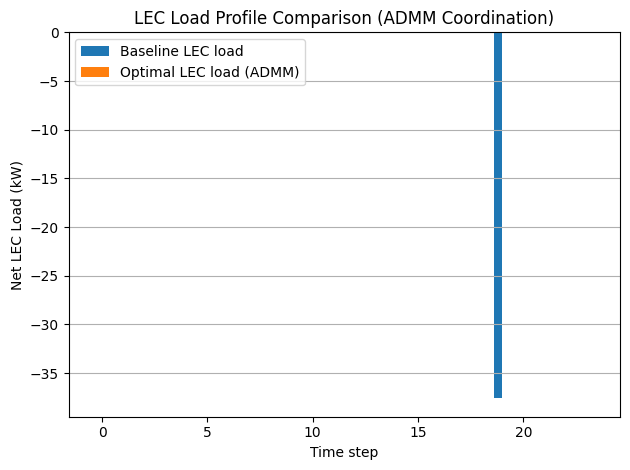

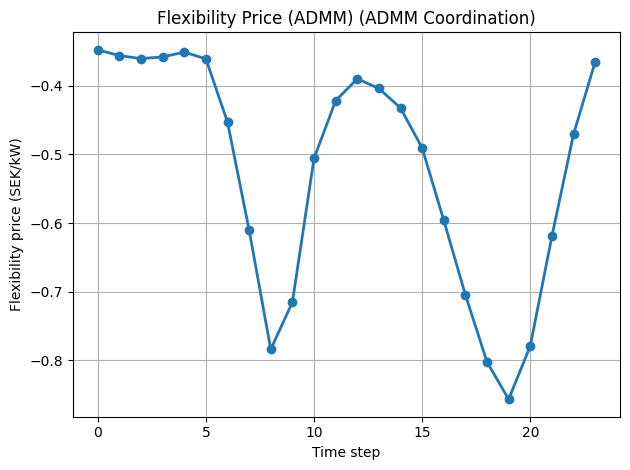

================ LEC COST SUMMARY ================
Baseline energy cost : -6.99 SEK
Optimal energy cost  : 25.21 SEK
Extra cost          : 32.19 SEK


In [155]:
def plot_lec_load_and_cost(
    df_baseline,
    df_optimal,
    spot_prices,
    flex_price,
    timestep_hours=0.25,
    title_suffix=""
):
    """
    Compare baseline and optimal LEC load profiles and energy cost.

    Parameters
    ----------
    df_baseline : pd.DataFrame
        Results from baseline LEC optimization
    df_optimal : pd.DataFrame
        Results from ADMM-optimal LEC optimization
    spot_prices : list or array
        Spot prices [SEK/kWh]
    timestep_hours : float
        Length of one timestep (default 0.25 for 15 min)
    title_suffix : str
        Optional string to add to plot title
    """

    T = len(spot_prices)
    flex_prices = flex_price
    # -----------------------------
    # Net LEC load (import - export)
    # -----------------------------
    P_base = np.array(df_baseline['P_import']) - np.array(df_baseline['P_export'])
    P_opt = np.array(df_optimal['P_import']) - np.array(df_optimal['P_export'])

    # -----------------------------
    # Energy cost calculation
    # -----------------------------
    cost_base = pyo.value(opt_baseline.model.base_obj)

    cost_opt = pyo.value(opt_lec.model.base_obj)

    cost_saving = - (cost_base - cost_opt)

    # -----------------------------
    # Plot load profiles
    # -----------------------------
    T = len(P_base)
    x = np.arange(T)

    bar_width = 0.4

    plt.figure()

    plt.bar(
        x - bar_width / 2,
        P_base,
        width=bar_width,
        label='Baseline LEC load'
    )

    plt.bar(
        x + bar_width / 2,
        P_opt,
        width=bar_width,
        label='Optimal LEC load (ADMM)'
    )

    plt.xlabel('Time step')
    plt.ylabel('Net LEC Load (kW)')
    plt.title(f'LEC Load Profile Comparison {title_suffix}')
    plt.legend()
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(x, flex_prices, linewidth=2, marker='o')

    plt.xlabel('Time step')
    plt.ylabel('Flexibility price (SEK/kW)')
    plt.title(f'Flexibility Price (ADMM) {title_suffix}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Print cost summary
    # -----------------------------
    print('================ LEC COST SUMMARY ================')
    print(f'Baseline energy cost : {cost_base:.2f} SEK')
    print(f'Optimal energy cost  : {cost_opt:.2f} SEK')
    print(f'Extra cost          : {cost_saving:.2f} SEK')
    print('==================================================')

    # -----------------------------
    # Return results for further use
    # -----------------------------
    return {
        'P_baseline': P_base,
        'P_optimal': P_opt,
        'cost_baseline': cost_base,
        'cost_optimal': cost_opt,
        'cost_saving': cost_saving
    }
df_baseline = opt_baseline.get_results()

# Optimal (final ADMM iteration)
df_optimal = opt_lec.get_results()

results = plot_lec_load_and_cost(
    df_baseline=df_baseline,
    df_optimal=df_optimal,
    spot_prices=spot_prices,
    flex_price=flex_price,
    timestep_hours=0.25,
    title_suffix="(ADMM Coordination)"
)

In [156]:
P_lec_net = [
    float(df_optimal['P_import'].iloc[t] - df_optimal['P_export'].iloc[t])  # kW
    for t in range(T)
]

In [157]:
ac_results = []
line_loading = []
for t in range(T):
    net_t = copy.deepcopy(net)
    loading_t = []
    # Convert kW → MW
    P_mw = P_lec_net[t] / 1000

    # Add fixed injection (positive = generation, negative = load)
    if P_mw >= 0:
        pp.create_sgen(
            net_t,
            bus=bus_mapping_inv[f"{lec_bus_dso}"],
            p_mw=P_mw,
            q_mvar=0.0,
            controllable=False
        )
    else:
        pp.create_load(
            net_t,
            bus=bus_mapping_inv[f"{lec_bus_dso}"],
            p_mw=P_mw,
            q_mvar=0.0,
            controllable=False
        )

    # Run AC OPF
    try:
        pp.runopp(net_t, verbose=False)
        status = "feasible"
    except:
        status = "infeasible"

    ac_results.append({
        "t": t,
        "status": status,
        "max_vm_pu": net_t.res_bus.vm_pu.max() if status == "feasible" else None,
        "min_vm_pu": net_t.res_bus.vm_pu.min() if status == "feasible" else None,
        "max_line_loading": net_t.res_line.loading_percent.max() if status == "feasible" else None
    })
    loading_t.append(net.res_line.loading_percent)
    line_loading.append(max(loading_t))
ac_results = pd.DataFrame(ac_results)

no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are given - overall generated power is minimized
no costs are g

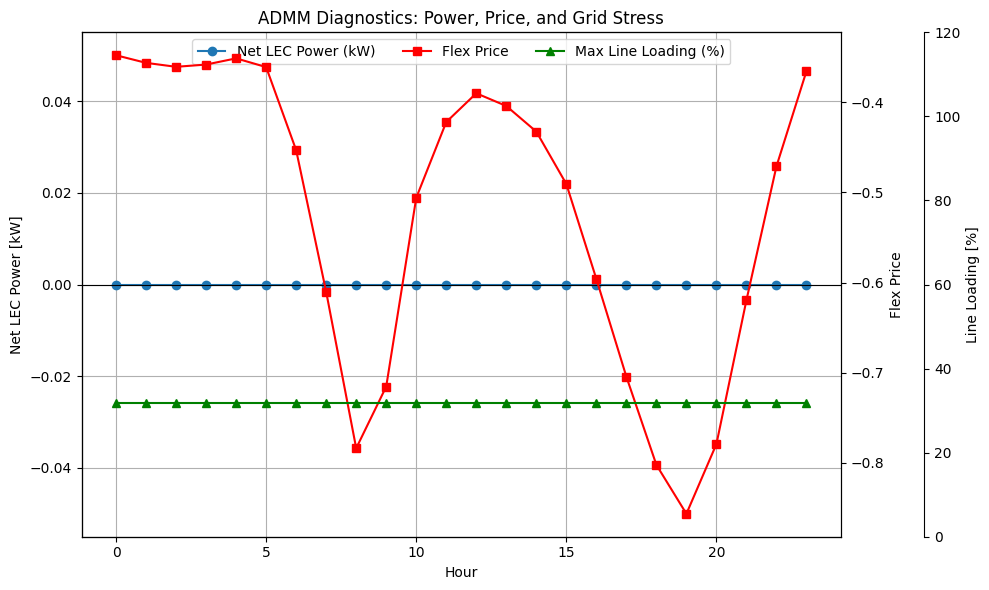

In [158]:
import matplotlib.pyplot as plt
import numpy as np

hours = np.arange(T)

fig, ax1 = plt.subplots(figsize=(10,6))

# -------------------------------------------------
# Net LEC Power (left axis)
# -------------------------------------------------
ax1.plot(hours, P_lec_net, marker='o', label='Net LEC Power (kW)')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Net LEC Power [kW]')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.grid(True)

# -------------------------------------------------
# Flex price (right axis)
# -------------------------------------------------
ax2 = ax1.twinx()
ax2.plot(hours, flex_price, color='red', marker='s', label='Flex Price')
ax2.set_ylabel('Flex Price')

# -------------------------------------------------
# Line loading (third axis)
# -------------------------------------------------
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(hours, ac_results['max_line_loading'], color='green', marker='^', label='Max Line Loading (%)')
ax3.set_ylabel('Line Loading [%]')
ax3.set_ylim(0, 120)

# -------------------------------------------------
# Legend
# -------------------------------------------------
lines, labels = [], []
for ax in [ax1, ax2, ax3]:
    l, lab = ax.get_legend_handles_labels()
    lines += l
    labels += lab

ax1.legend(lines, labels, loc='upper center', ncol=3)

plt.title('ADMM Diagnostics: Power, Price, and Grid Stress')
plt.tight_layout()
plt.show()
